#Возьмем преобразованные данные из ДЗ №4
*для ДЗ №5 пролистать ниже*

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [ ]:
df = pd.read_csv("/content/loan_prediction_dataset.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
display(df.info())
display(df.describe())
display(df.describe(include="object"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


None

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [ ]:
missing_df_before = pd.DataFrame({
    'Absolute Missing': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_df_before[missing_df_before['Absolute Missing'] > 0]

,Absolute Missing,Percentage (%)
Gender,13,2.117264
Married,3,0.488599
Dependents,15,2.442997
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Loan_Amount_Term,14,2.280130
Credit_History,50,8.143322


<Figure size 640x480 with 0 Axes>

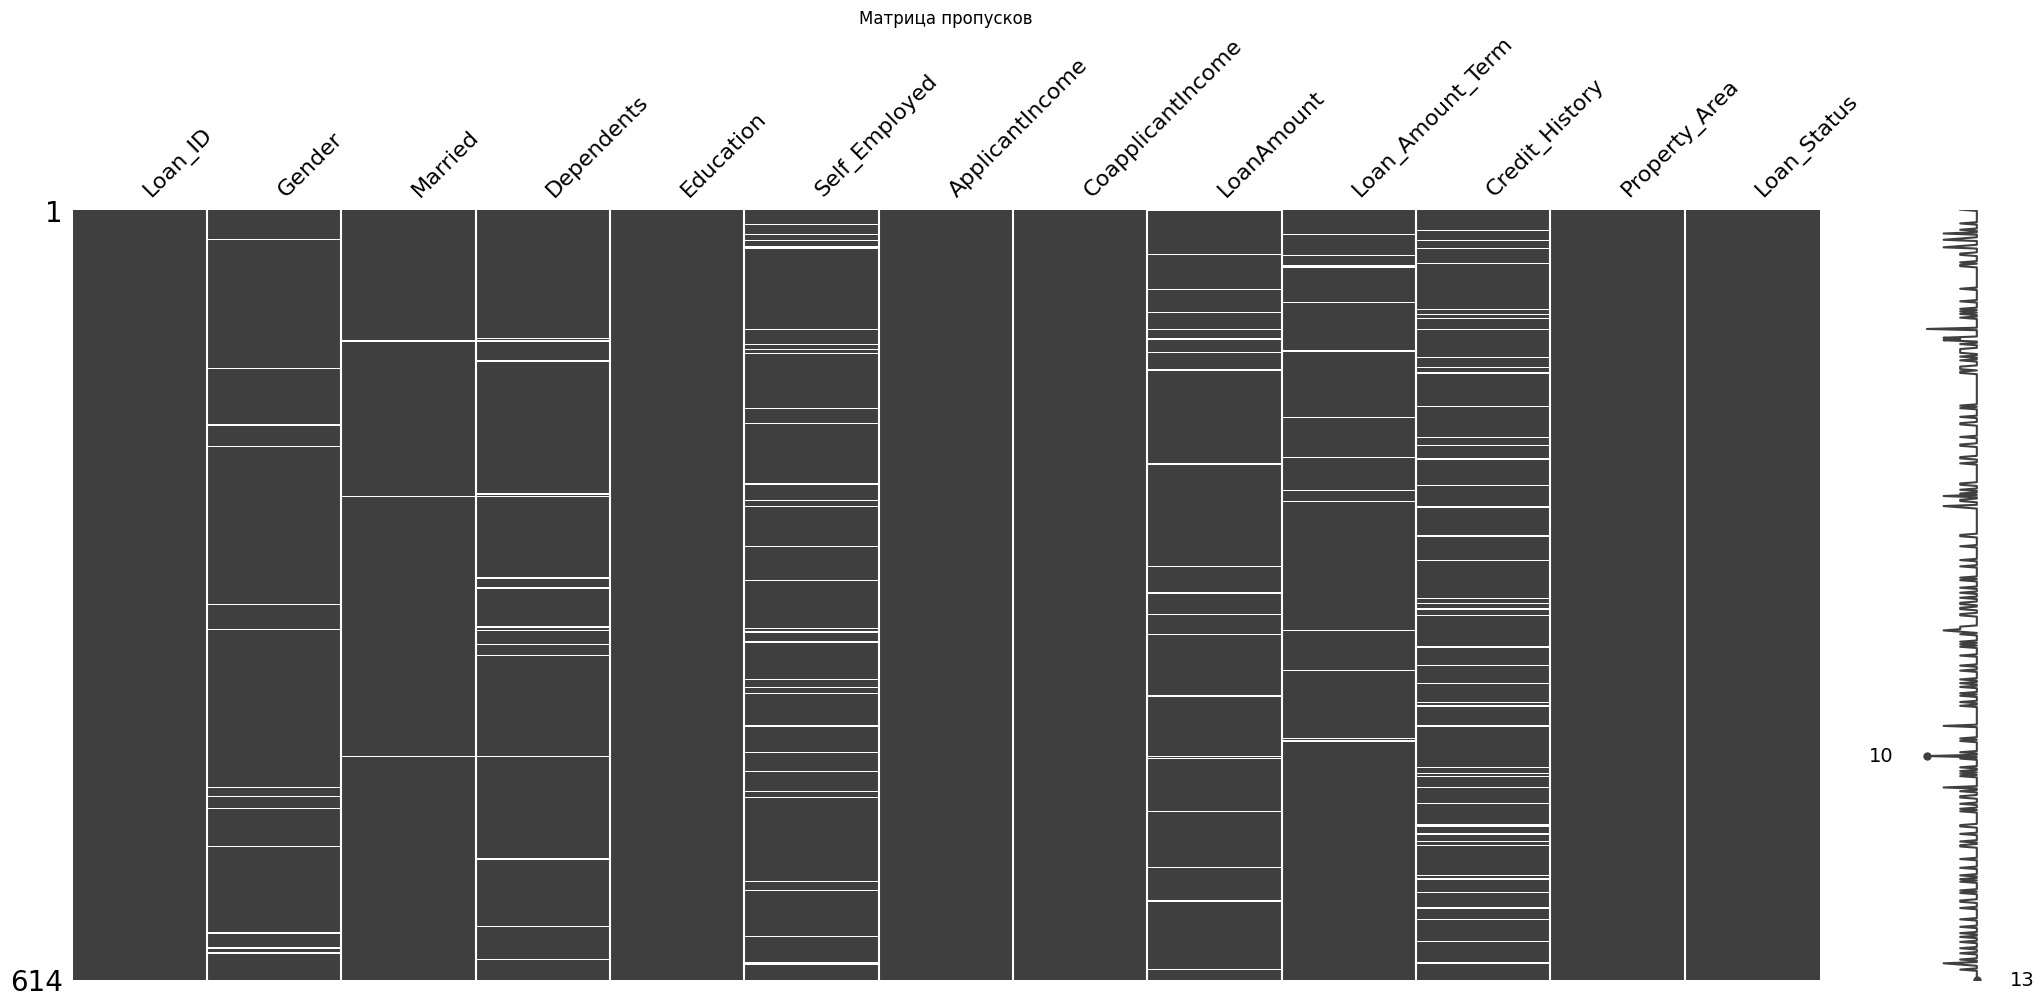

In [ ]:
plt.figure()
msno.matrix(df)
plt.title("Матрица пропусков")
plt.show()

<Figure size 1000x1000 with 0 Axes>

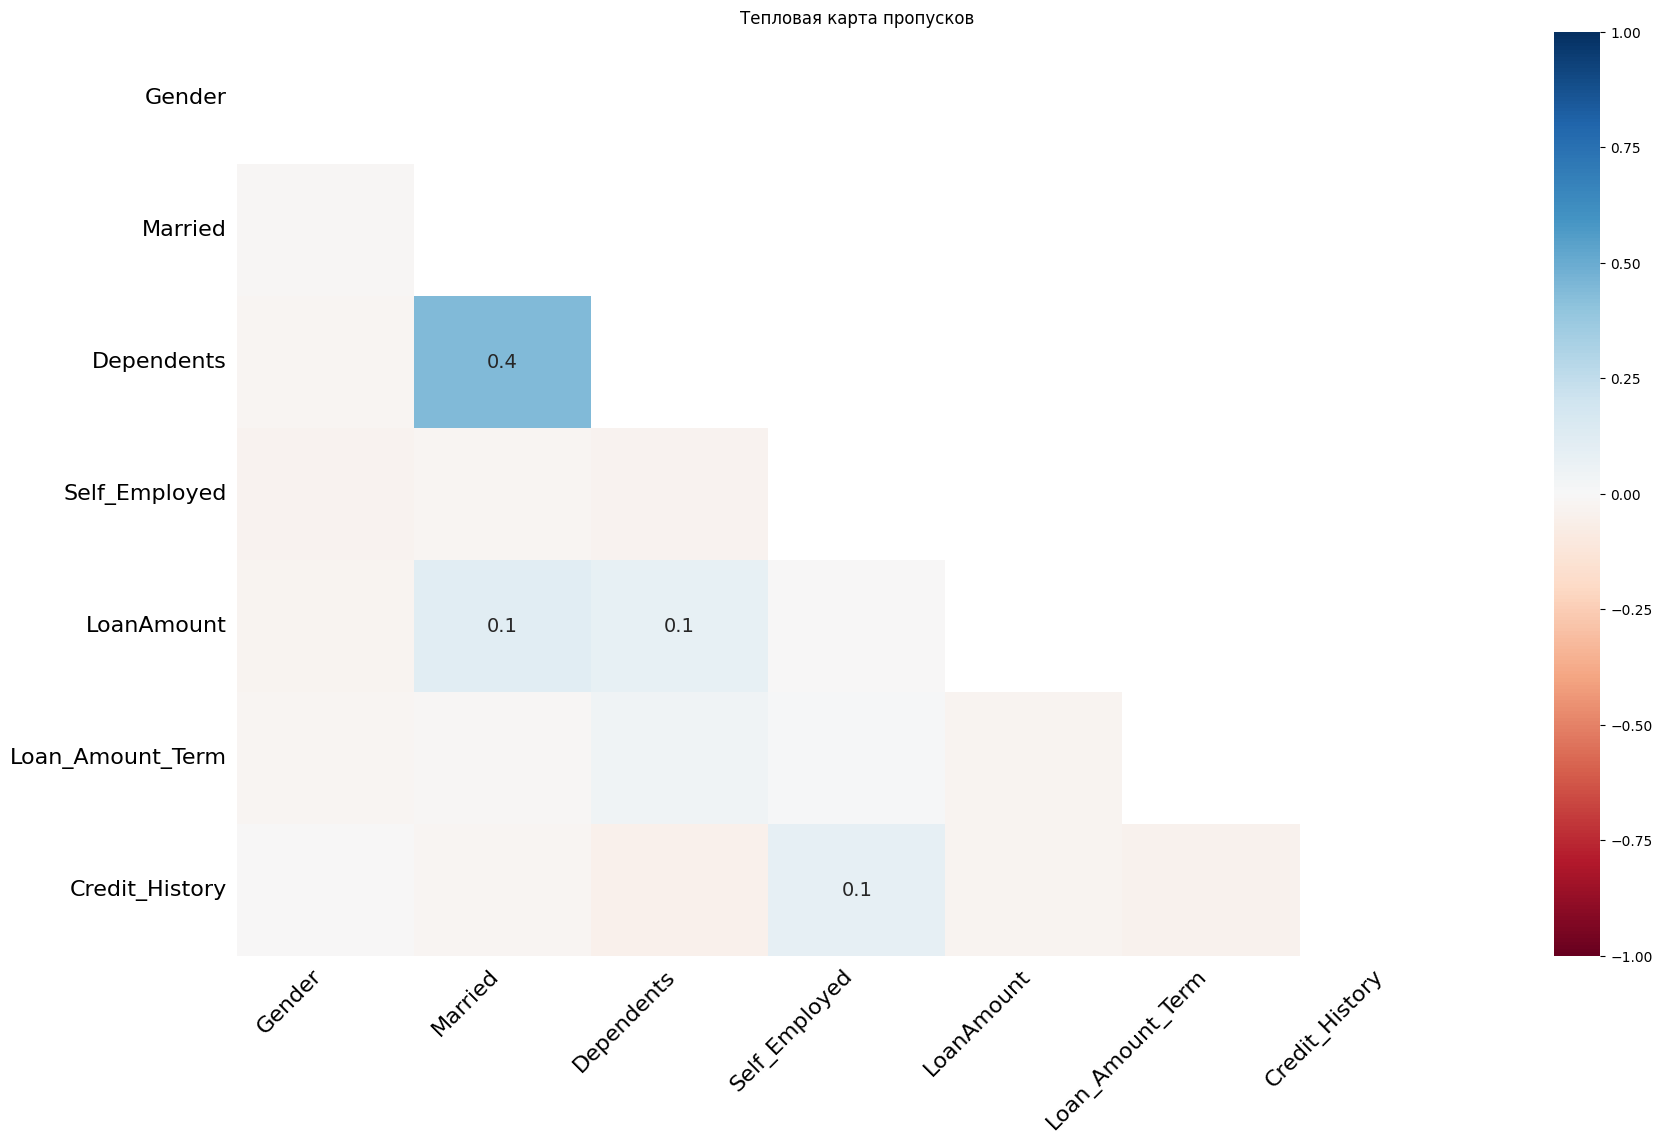

In [ ]:
plt.figure(figsize=(10, 10))
msno.heatmap(df)
plt.title('Тепловая карта пропусков')
plt.show()

In [ ]:
cols_with_na = df.columns[df.isnull().any()].tolist()

print('Числовые признаки: ',df[cols_with_na].select_dtypes(include=['number']).columns.tolist())
print('Категориальные признаки: ',df[cols_with_na].select_dtypes(include=['object']).columns.tolist())

Числовые признаки:  ['LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Категориальные признаки:  ['Gender', 'Married', 'Dependents', 'Self_Employed']


In [ ]:
numeric_missing = df[cols_with_na].select_dtypes(include=['number']).columns.tolist()
categorical_missing = df[cols_with_na].select_dtypes(include=['object']).columns.tolist()

In [ ]:
categorical_stats_before = (
    df[categorical_missing]
    .describe()
    .T
    .assign(
        top_share=lambda x: x["freq"] / x["count"]*100,
        missing_share=df[categorical_missing].isnull().mean()*100
    )
)

categorical_stats_before

,count,unique,top,freq,top_share,missing_share
Gender,601,2,Male,489,81.364393,2.117264
Married,611,2,Yes,398,65.139116,0.488599
Dependents,599,4,0,345,57.595993,2.442997
Self_Employed,582,2,No,500,85.910653,5.211726


In [ ]:
for col in categorical_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_518/1860304347.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
numeric_stats_before = (
    df[numeric_missing]
    .describe()
    .T
    .assign(
        median=df[numeric_missing].median(),
        missing_share=df[numeric_missing].isnull().mean() * 100
    )
)

numeric_stats_before

,count,mean,std,min,25%,50%,75%,max,median,missing_share
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0,128.0,3.583062
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.0,480.0,360.0,2.280130
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.0,1.0,1.0,8.143322


In [ ]:
for col in numeric_missing:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_518/1072432271.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [ ]:
display(df.describe(include="object"))

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,614,614,614,614,614,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,502,401,360,480,532,233,422


In [ ]:
missing_df_after = pd.DataFrame({
    'Absolute Missing': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})

missing_df_after

,Absolute Missing,Percentage (%)
Loan_ID,0,0.0
Gender,0,0.0
Married,0,0.0
Dependents,0,0.0
Education,0,0.0
Self_Employed,0,0.0
ApplicantIncome,0,0.0
CoapplicantIncome,0,0.0
LoanAmount,0,0.0
Loan_Amount_Term,0,0.0


In [ ]:
categorical_stats_before

In [ ]:
categorical_stats_after = (
    df[categorical_missing]
    .describe()
    .T
    .assign(
        top_share=lambda x: x["freq"] / x["count"]*100,
        missing_share=df[categorical_missing].isnull().mean()*100
    )
)

categorical_stats_after

In [ ]:
numeric_stats_before

,count,mean,std,min,25%,50%,75%,max,median,missing_share
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0,128.0,3.583062
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.0,480.0,360.0,2.280130
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.0,1.0,1.0,8.143322


In [ ]:
numeric_stats_after = (
    df[numeric_missing]
    .describe()
    .T
    .assign(
        median=df[numeric_missing].median(),
        missing_share=df[numeric_missing].isnull().mean() * 100
    )
)

numeric_stats_after

,count,mean,std,min,25%,50%,75%,max,median,missing_share
LoanAmount,614.0,145.752443,84.107233,9.0,100.25,128.0,164.75,700.0,128.0,0.0
Loan_Amount_Term,614.0,342.410423,64.428629,12.0,360.00,360.0,360.00,480.0,360.0,0.0
Credit_History,614.0,0.855049,0.352339,0.0,1.00,1.0,1.00,1.0,1.0,0.0


# Домашнее задание № 5

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# Найдем выбросы для `ApplicantIncome` и `LoanAmount`

## 1. IQR-правило

In [ ]:
def detect_outliers_iqr(df, column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Outliers count: {len(outliers)}")

    return outliers

In [ ]:
outliers_income_iqr = detect_outliers_iqr(df, "ApplicantIncome")

outliers_loan_iqr = detect_outliers_iqr(df, "LoanAmount")

ApplicantIncome
Lower bound: -1498.75
Upper bound: 10171.25
Outliers count: 50
LoanAmount
Lower bound: 3.5
Upper bound: 261.5
Outliers count: 41


## 2. Метод стандартного отклонения

In [ ]:
def detect_outliers_std(df, column):

    mean = df[column].mean()
    std = df[column].std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Outliers count: {len(outliers)}")

    return outliers

In [ ]:
outliers_income_std = detect_outliers_std(df, "ApplicantIncome")

outliers_loan_std = detect_outliers_std(df, "LoanAmount")

ApplicantIncome
Lower bound: -12923.665736773899
Upper bound: 23730.584303549145
Outliers count: 8
LoanAmount
Lower bound: -106.56925714453578
Upper bound: 398.0741431380211
Outliers count: 15


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=df["ApplicantIncome"], ax=axes[0])
axes[0].set_title("ApplicantIncome")

sns.boxplot(y=df["LoanAmount"], ax=axes[1])
axes[1].set_title("LoanAmount")

plt.show()

Способ IQR выявляет значения, выходящие за пределы диапазона [Q1 − 1.5×IQR, Q3 + 1.5×IQR].

Метод стандартного отклонения определяет выбросы как значения, находящиеся за пределами mean ± 3×std. Оба метода позволяют обнаружить экстремальные значения дохода заявителей и суммы кредита.

Метод межквартильного размаха отобразил 50 выбросов.
Метод стандартного отклонения дал 8 выбросов для параметра ApplicantIncome и
41 и 15 соотвественно для параметра LoanAmount.

Т.е. IQR показывает значительно больше выбросов.
Исходя из этого можно сделать вывод о том, что наиболее экстремальными выбросами будут являться значения, попавшие в пересечение этих двух методов.

# Построим гистограммы для визуализации распределения

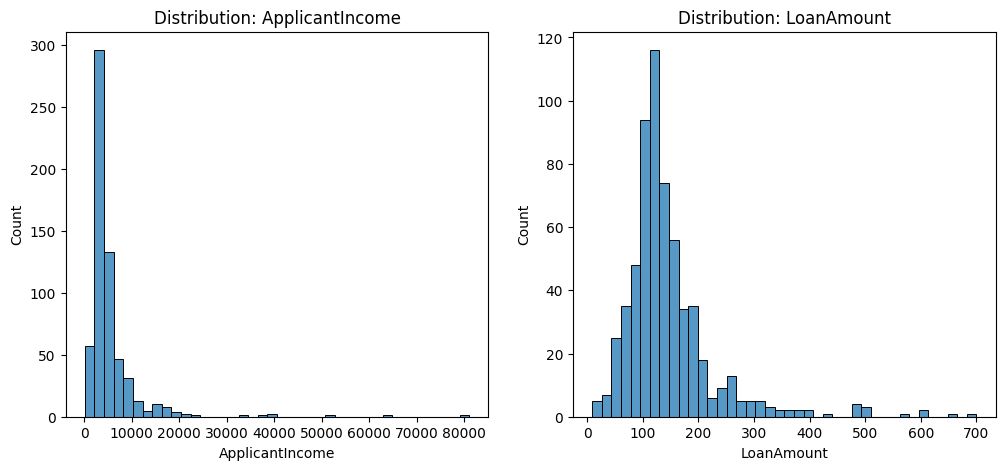

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df["ApplicantIncome"], bins=40, ax=axes[0])
axes[0].set_title("Distribution: ApplicantIncome")

sns.histplot(df["LoanAmount"], bins=40, ax=axes[1])
axes[1].set_title("Distribution: LoanAmount")

plt.show()

На графиках наблюдается ассиметричное распределение данных. О выбросах свидетельствуют "хвосты" графиков - единичные значения, разбросанные вправо по оси Х.

Как мы можем увидеть, выбросы здесь - экстремальные значения реальных данных, а не ошибки. Более того, разные методы идентификации выбросов демонстрируют разительные различия при одном и том же датасете.

Все это говорит нам о том, что удаление выбросов нецелесообразно: таким образом мы нарушим полноту данных.

**Принимаем решение оставить датасет в оригинальном виде.**

In [ ]:
newdf = df

In [ ]:
newdf

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


# Снова подсветим категориальные признаки в датасете:

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

Список выглядит следующим образом:

*   Gender
*   Married
*   Dependents
*   Education
*   Self_Employed
*   Property_Area
*   Loan_Status

Из них признки ```Gender, Married, Education, Self_Employed, Loan_Status ```являются бинарными.

###1. ```Gender```
Значения
- Male
- Female



###2. ```Married```

Значения:

- Yes
- No

###3. ```Education```

Значения:

- Graduate
- Not Graduate

### 4. ```Self_Employed```

Значения:

- Yes
- No

### ```Loan_Status```

Значения:

- Y
- N

In [ ]:
newdf["Gender"] = newdf["Gender"].map({"Male": 1, "Female": 0})
newdf["Married"] = newdf["Married"].map({"Yes": 1, "No": 0})
newdf["Education"] = newdf["Education"].map({"Graduate": 1, "Not Graduate": 0})
newdf["Self_Employed"] = newdf["Self_Employed"].map({"Yes": 1, "No": 0})
newdf["Loan_Status"] = newdf["Loan_Status"].map({"Y": 1, "N": 0})

### 6.```Property_Area```

Значения:

- Urban
- Semiurban
- Rural

В данном случае наиболее корректно испольковать one-hot-encoding, поскольку данные не являются порядковыми и требуется избегать ложной интерпретации.

In [ ]:
newdf = pd.get_dummies(newdf, columns=["Property_Area"], drop_first=True)

### 7. ```Dependents```

Значения:
- 0
- 1
- 2
- 3+

В данном случае данные являются порядковыми, а значит можно применить порядковое кодирование

In [ ]:
newdf["Dependents"] = newdf["Dependents"].replace({"0": 0, "1": 1, "2": 2, "3+": 3}).astype(int)

/tmp/ipykernel_518/2158618450.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  newdf["Dependents"] = newdf["Dependents"].replace({"0": 0, "1": 1, "2": 2, "3+": 3}).astype(int)


In [ ]:
newdf

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,False,True
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,0,0,0,1,0,2900,0.0,71.0,360.0,1.0,1,False,False
610,LP002979,1,1,3,1,0,4106,0.0,40.0,180.0,1.0,1,False,False
611,LP002983,1,1,1,1,0,8072,240.0,253.0,360.0,1.0,1,False,True
612,LP002984,1,1,2,1,0,7583,0.0,187.0,360.0,1.0,1,False,True


In [ ]:
newdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    int64  
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    bool   
 13  Property_Area_Urban      614 non-null    bool   
dtypes: bool(2), float64(4), in

Можем наблюдать, что все категориальные признаки преобразованы к числовым.

In [ ]:
newdf.shape

(614, 14)

Количество строк не изменилось, кол-во столбцов увеличилось соответсвенно one-hot-encoding

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


Пропуски и ошибки отсутствуют